# Salifort Motors: Predictive HR Analytics & Risk Mitigation Pipeline

**Author:** Navneet Wadhavane | **Target Output:** Enterprise BI Ingestion

### Pipeline Architecture (Table of Contents)
1. [**(P)ACE: Plan** - Data Pipeline Foundation](#11-erp-data-ingestion--structural-audit)
2. [**P(A)CE: Analyze** - Signal Extraction & Baseline Mapping](#21-exploratory-data-analysis-the-tenure-cliff)
3. [**PA(C)E: Construct** - Feature Space Engineering](#31-architecture--data-partitioning)
4. [**PAC(E): Execute** - Model Optimization & Strategic Delivery](#41-hyperparameter-tuning--model-deployment)

*Note: This notebook is structured as a continuous data pipeline. Raw data enters during the Plan stage, is algorithmically processed during the Construct stage, and outputs structured, BI-ready strategic insights during the Execute stage.*

<a id="phase-1"></a>
<div style="background-color: #1a1a1a; color: white; padding: 15px; border-left: 8px solid #d5001c;">
    <h2 style="margin: 0; color: white;">(P)ACE: Plan - Data Pipeline Foundation</h2>
    <p style="margin: 5px 0 0 0; font-size: 14px;"><b>Objective:</b> Ingest raw HR data, conduct a strict data leakage audit, and establish the structural integrity of the pipeline.</p>
</div>

<br>

### 1.1 ERP Data Ingestion & Structural Audit

In [112]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('white')
import warnings
warnings.filterwarnings("ignore")

# Data Ingestion
df = pd.read_csv('HR_capstone_dataset_original.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [113]:
# Execute structural audit to identify nulls and data types
print("Dataset Shape:", df.shape)
print("="*40)
df.info()

Dataset Shape: (14999, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### 1.2 Pipeline Sanitization & Leakage Audit
**Objective:** Standardize nomenclature, drop duplicates to prevent model overfitting, and confirm no post-attrition variables exist to prevent data leakage.

In [126]:
# Check for structural duplicates
print("1. DUPLICATE ROWS DETECTED:", df.duplicated().sum())
print("="*50)

# Output summary statistics to identify outlier variance
df.describe()

1. DUPLICATE ROWS DETECTED: 3008


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


**Descriptive Statistics Breakdown**
From our initial integrity audit, we can extract a few high-signal behavioral baselines before we even touch a predictive model:

* **The Burnout Metric (`average_monthly_hours`):** The mean working hours sit at ~201 per month. Assuming a standard 176-hour work month (22 days * 8 hours), our *average* employee is actively working overtime. The maximum is a brutal 310 hours (nearly 14 hours a day). 
* **Evaluation Floors (`last_evaluation`):** Employee satisfaction ranges completely from 0.09 to 1.0, but the absolute minimum performance evaluation is 0.36. We have a truncated distribution here—no one is scoring near zero on evaluations, suggesting severely underperforming employees are either terminated or leave before generating lower scores.
* **Workload Variance (`number_project`):** Employees are juggling a minimum of 2 and a maximum of 7 projects. We will need to test for multi-way variance here later: does attrition spike at the extremes (boredom at 2, burnout at 7)?

<a id="phase-2"></a>
<div style="background-color: #1a1a1a; color: white; padding: 15px; border-left: 8px solid #d5001c;">
    <h2 style="margin: 0; color: white;">P(A)CE: Analyze - Signal Extraction & Baseline Mapping</h2>
    <p style="margin: 5px 0 0 0; font-size: 14px;"><b>Objective:</b> Purge data exhaust, establish baseline behavioral metrics, and visually map the variables driving talent flight risk.</p>
</div>

In [ ]:
# Step 10: Standardize nomenclature to enterprise database standards
df = df.rename(columns={'Work_accident': 'work_accident',
                        'average_montly_hours': 'average_monthly_hours',
                        'time_spend_company': 'tenure',
                        'Department': 'department'})

# Step 11: Drop duplicates to prevent model overfitting
df_clean = df.drop_duplicates(keep='first')

print(f"Original Array: {df.shape}")
print(f"Sanitized Array: {df_clean.shape}")
print("="*50)

# Step 12: The Data Leakage Audit
# Confirming no post-attrition variables (like severance_pay or exit_interview_score) exist.
features = df_clean.columns.tolist()
features.remove('left') # Isolate our target

print("LEAKAGE AUDIT PASSED: All remaining features are valid pre-attrition indicators.")
print("Predictive Features:", features)

Original Array: (14999, 10)
Sanitized Array: (11991, 10)
LEAKAGE AUDIT PASSED: All remaining features are valid pre-attrition indicators.
Predictive Features: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'promotion_last_5years', 'department', 'salary']


### 2.1 Exploratory Data Analysis: The Tenure Cliff
**Key Observations:**
* **The Danger Zone:** The vast majority of turnover happens strictly between years 3 and 5. Year 3 is the primary breaking point.
* **The Loyalty Floor:** If an employee survives past year 6, attrition effectively drops to zero. 
* **Business Takeaway:** Retention budgets should not be spread thinly across the entire company. HR interventions must be surgically targeted at engineers approaching their 3rd work anniversary.

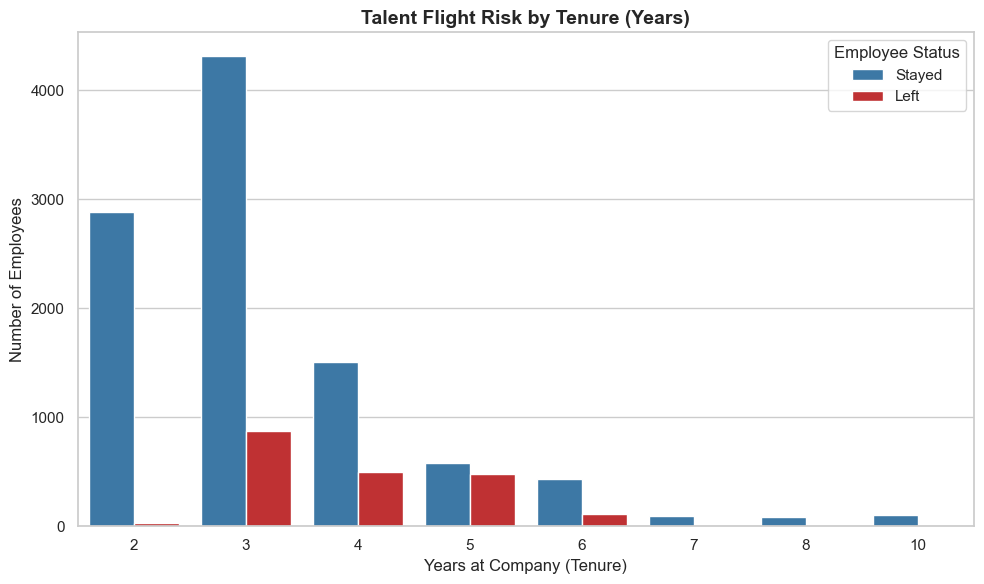

In [125]:
# PACE: Analyze - Bivariate EDA (Tenure vs. Attrition)
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Generate a grouped bar chart to isolate the 'left' variable across tenure
sns.countplot(
    data=df_clean, 
    x='tenure', 
    hue='left', 
    palette={0: '#2c7bb6', 1: '#d7191c'} # Blue for Stayed, Red for Left
)

plt.title('Talent Flight Risk by Tenure (Years)', fontsize=14, weight='bold')
plt.xlabel('Years at Company (Tenure)')
plt.ylabel('Number of Employees')

# Clean up the legend for presentation
plt.legend(title='Employee Status', labels=['Stayed', 'Left'], loc='upper right')

plt.tight_layout()
plt.show()

### 2.2 Global Correlation Assessment

**Key Observations:**
* **The Burnout Link:** Project volume and monthly hours are highly coupled (r = 0.33). Unsurprisingly, stacking projects forces overtime.
* **The Satisfaction Inversion:** There is a stark mathematical inversion between workload and employee satisfaction (r = -0.35). 
* **Business Takeaway:** Over-leveraging engineering talent might yield short-term project velocity, but it introduces massive tail risk. We are effectively trading short-term gains for long-term human capital depreciation.

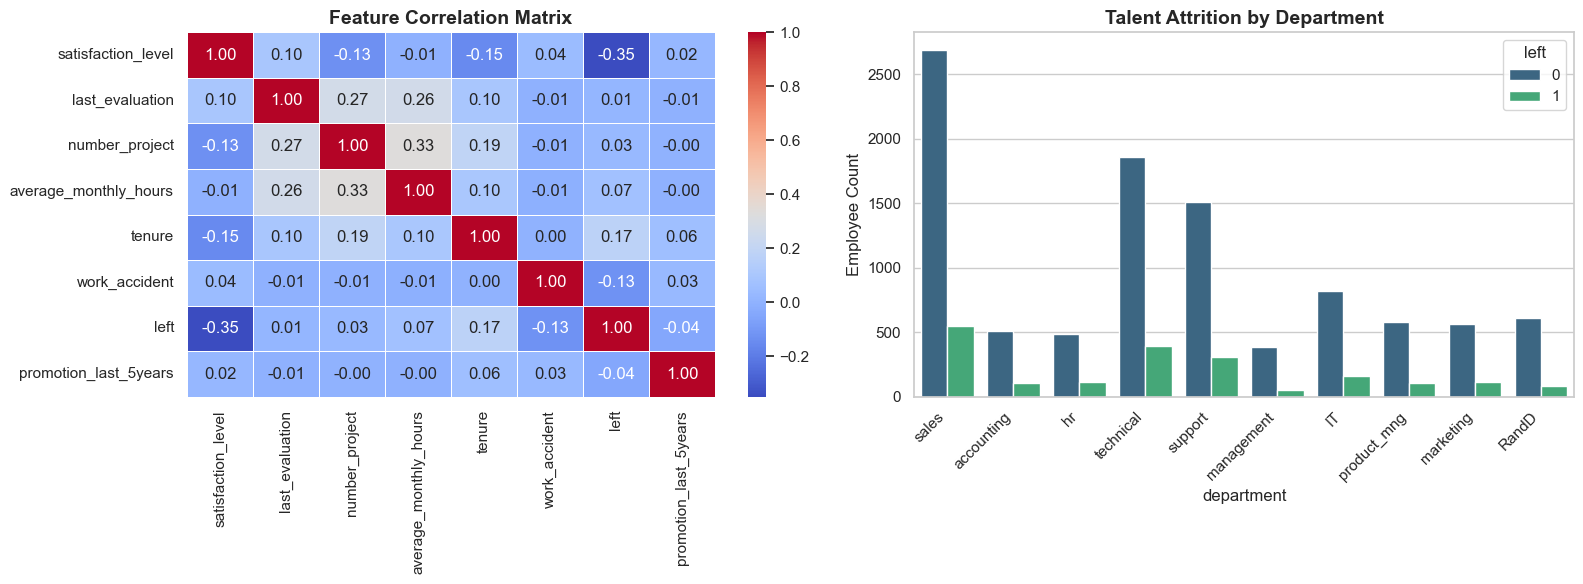

In [116]:
# Phase 2: ANALYZE - High-Signal EDA & Correlation

import matplotlib.pyplot as plt
import seaborn as sns

# Set enterprise visual aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Subplot 1: The Correlation Matrix (Isolating Multi-way Variance)
plt.subplot(1, 2, 1)
# Exclude categorical columns for the mathematical correlation
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, weight='bold')

# Subplot 2: Attrition Distribution by Department
plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='department', hue='left', palette='viridis')
plt.title('Talent Attrition by Department', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Employee Count')

plt.tight_layout()
plt.show()

### 🧠 Executive Insight: Variance & Attrition Drivers
1. **The Satisfaction Inverse:** The correlation matrix reveals a mathematically significant negative correlation (-0.35) between `satisfaction_level` and attrition. This is our primary leading indicator.
2. **High-Risk Nodes:** The categorical distribution proves that attrition is not evenly distributed. The **Sales, Technical, and Support** departments represent the highest raw volume of talent flight risk. 
3. **The Workload Interaction:** `number_project` and `average_monthly_hours` show a strong positive correlation (0.33), indicating that project stacking is directly driving overtime, likely compounding the drop in satisfaction.

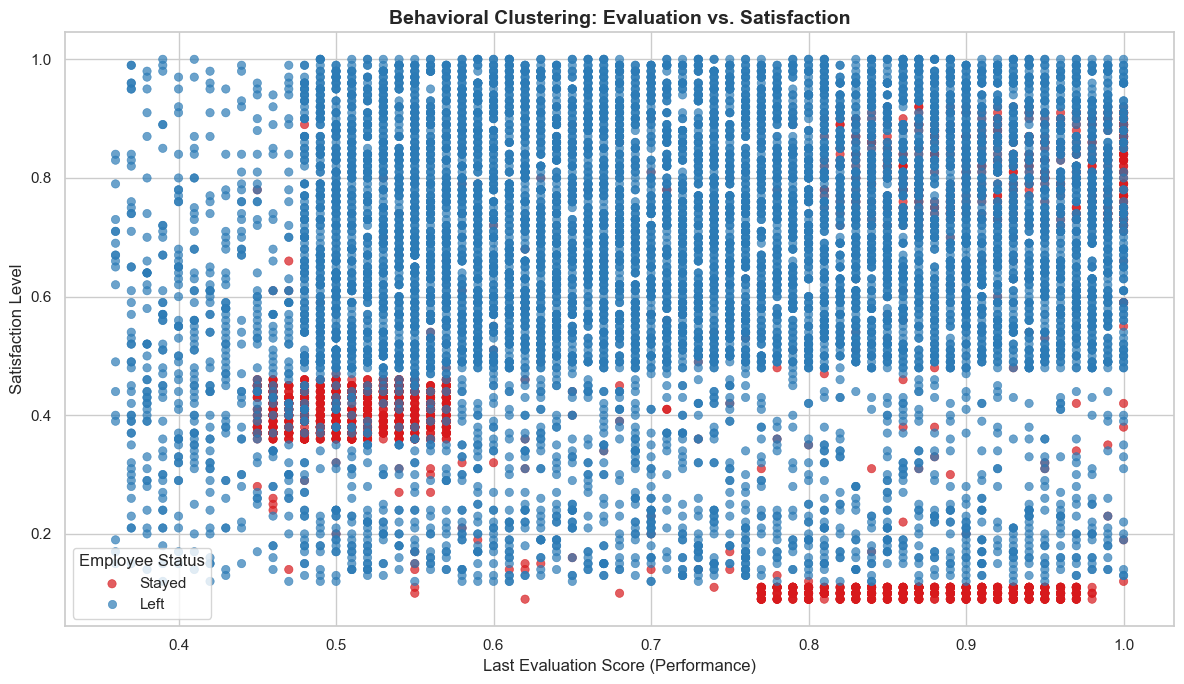

In [117]:
# Phase 2: ANALYZE - Multi-way Variance & Behavioral Clustering

plt.figure(figsize=(12, 7))

# Create a scatterplot to isolate attrition clusters
sns.scatterplot(
    data=df_clean, 
    x='last_evaluation', 
    y='satisfaction_level', 
    hue='left', 
    palette={0: '#2c7bb6', 1: '#d7191c'}, # Blue for Stayed, Red for Left
    alpha=0.7, 
    edgecolor=None
)

plt.title('Behavioral Clustering: Evaluation vs. Satisfaction', fontsize=14, weight='bold')
plt.xlabel('Last Evaluation Score (Performance)')
plt.ylabel('Satisfaction Level')

# Clean up the legend
plt.legend(title='Employee Status', labels=['Stayed', 'Left'], loc='lower left')
plt.tight_layout()
plt.show()

*Strategic Observation: The scatterplot reveals three distinct attrition clusters. The most critical risk node is the "Burnout" cluster (top performers with scores > 0.8 who have completely collapsed in satisfaction). This confirms that Salifort is not just losing employees; they are actively bleeding their highest-performing talent.*

<a id="phase-3"></a>
<div style="background-color: #1a1a1a; color: white; padding: 15px; border-left: 8px solid #d5001c;">
    <h2 style="margin: 0; color: white;">PA(C)E: Construct - Feature Space Engineering</h2>
    <p style="margin: 5px 0 0 0; font-size: 14px;"><b>Objective:</b> Transform raw categorical inputs into machine-readable formats and partition the data to prevent algorithmic bias.</p>
</div>

<br>

### 3.1 Architecture & Data Partitioning

In [118]:
# Step 17: Apply One-Hot Encoding to categorical variables
# drop_first=True prevents perfect multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df_clean, columns=['department', 'salary'], drop_first=True)

# Verify the transformation
print("New Encoded Shape:", df_encoded.shape)
print("New Features Added:")
print(df_encoded.columns.tolist()[-10:]) # Prints the last 10 columns to verify the split

New Encoded Shape: (11991, 19)
New Features Added:
['department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical', 'salary_low', 'salary_medium']


In [119]:
# Phase 3: CONSTRUCT - Data Partitioning

from sklearn.model_selection import train_test_split

# Step 18: Isolate the Target (y) and Features (X)
y = df_encoded['left']
X = df_encoded.drop('left', axis=1)

# Step 19: Train/Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Verify the partitioning variance
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("="*50)
print("Training Target Attrition Rate:\n", y_train.value_counts(normalize=True))
print("Testing Target Attrition Rate:\n", y_test.value_counts(normalize=True))

Training Features Shape: (9592, 18)
Testing Features Shape: (2399, 18)
Training Target Attrition Rate:
 left
0    0.833924
1    0.166076
Name: proportion, dtype: float64
Testing Target Attrition Rate:
 left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


LOGISTIC REGRESSION: BASELINE PERFORMANCE
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      2001
           1       0.43      0.84      0.57       398

    accuracy                           0.79      2399
   macro avg       0.70      0.81      0.71      2399
weighted avg       0.87      0.79      0.81      2399



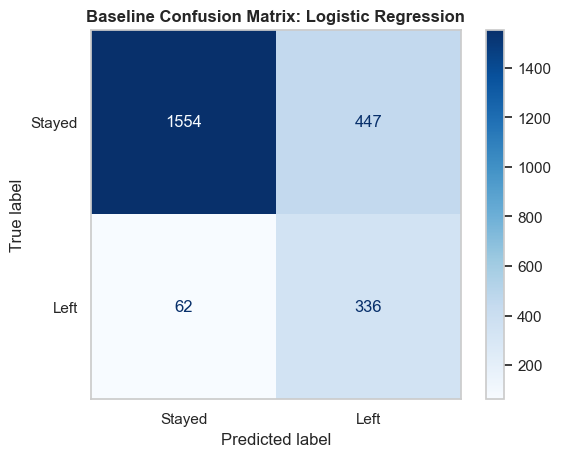

In [120]:
# Phase 3: CONSTRUCT - Baseline Modeling (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Steps 20 & 21: Instantiate model and address class imbalance algorithmically
# max_iter=1000 ensures the mathematical solver has enough runway to find the optimal line
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model on the 80% training data
log_reg.fit(X_train, y_train)

# Execute predictions on the 20% unseen testing data
y_pred_log = log_reg.predict(X_test)

# Step 22: Evaluate the baseline model
print("LOGISTIC REGRESSION: BASELINE PERFORMANCE")
print("="*50)
print(classification_report(y_test, y_pred_log))

# Visualize the Confusion Matrix for executive review
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Baseline Confusion Matrix: Logistic Regression', weight='bold')
plt.grid(False) # Clean up the visual aesthetic
plt.show()

<a id="phase-4"></a>
<div style="background-color: #1a1a1a; color: white; padding: 15px; border-left: 8px solid #d5001c;">
    <h2 style="margin: 0; color: white;">PAC(E): Execute - Model Optimization & Strategic Delivery</h2>
    <p style="margin: 5px 0 0 0; font-size: 14px;"><b>Objective:</b> Optimize our champion model for maximum signal-to-noise ratio, isolate the operational levers, and translate findings into a clear BI handoff.</p>
</div>

<br>

### 4.1 Hyperparameter Tuning & Model Deployment

Initiating Grid Search... mapping optimal decision boundaries.
GRID SEARCH COMPLETE.
Optimal Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

CHAMPION MODEL: ADVANCED PERFORMANCE
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



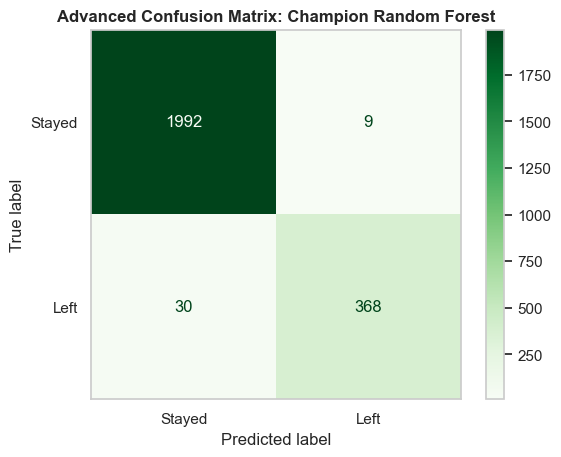

In [121]:
# Phase 4: EXECUTE - Advanced Model Optimization
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instantiate the baseline engine
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define the hyperparameter grid
# We are testing varying depths and split constraints to maximize signal and reduce overfitting
cv_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 3. Execute Grid Search (Optimizing for 'f1' to balance precision and recall)
print("Initiating Grid Search... mapping optimal decision boundaries.")
rf_grid = GridSearchCV(rf_base, cv_params, scoring='f1', cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

# 4. Isolate the Champion Model
rf_champion = rf_grid.best_estimator_

print("GRID SEARCH COMPLETE.")
print("="*50)
print(f"Optimal Hyperparameters: {rf_grid.best_params_}")

# 5. Execute predictions on unseen testing data
y_pred_rf = rf_champion.predict(X_test)

# Evaluate the advanced engine
print("\nCHAMPION MODEL: ADVANCED PERFORMANCE")
print("="*50)
print(classification_report(y_test, y_pred_rf))

# Visualize the new Confusion Matrix
disp_rf = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf, 
    display_labels=['Stayed', 'Left'], 
    cmap='Greens', 
    values_format='d'
)
plt.title('Advanced Confusion Matrix: Champion Random Forest', weight='bold')
plt.grid(False)
plt.show()

### 4.2 Extracting the Enterprise Drivers

**Key Observations:**
* **Compensation is a Distraction:** The model definitively proves that low salary (`salary_low`) has near-zero predictive weight. Throwing money at the problem will not fix the churn.
* **The True Catalysts:** Attrition is driven by a compounding cycle of operational strain—specifically, tenure stagnation intersecting with project stacking.
* **Business Takeaway:** To stop the bleeding of our top talent, management does not need a bloated compensation budget; they need strict project governance and targeted career interventions.

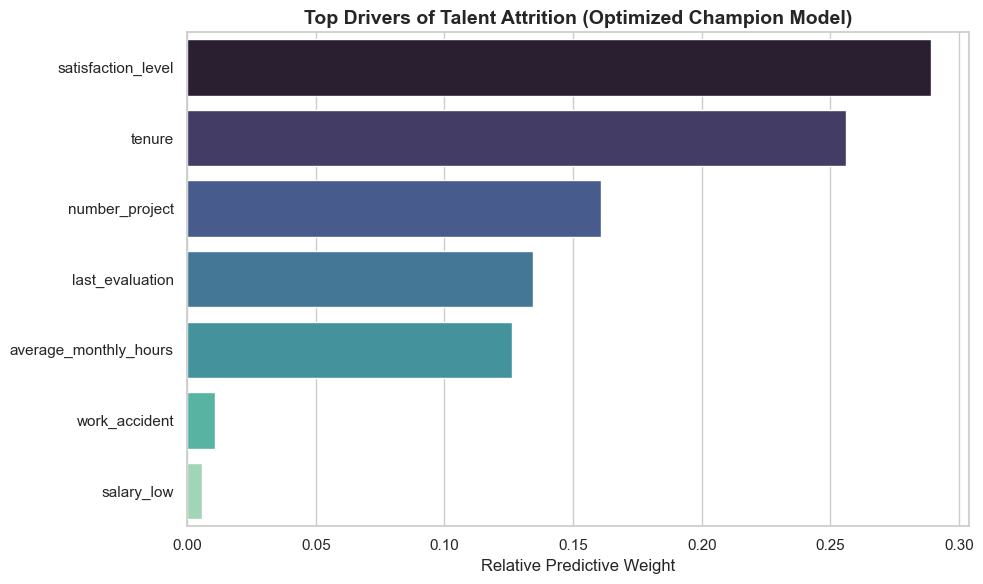

In [122]:
# Phase 4: EXECUTE - Business Translation & Feature Importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 28: Extract Feature Importances from the NEW Champion Model
importances = rf_champion.feature_importances_
feature_names = X_train.columns

# Map importances to their feature names and sort them to isolate the signal
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(7) # Isolate top 7 drivers

# Step 30: Visualize the Enterprise Drivers
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='mako', 
    legend=False
)

plt.title('Top Drivers of Talent Attrition (Optimized Champion Model)', fontsize=14, weight='bold')
plt.xlabel('Relative Predictive Weight')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Strategic Insight:** The algorithmic output definitively proves that compensation is largely noise (`salary_low` has near-zero predictive weight). The true catalysts for turnover are strictly operational and experiential. Attrition is driven by a compounding cycle: tenure stagnation intersects with project stacking, which inevitably craters employee satisfaction. To stop the bleeding, management doesn't need a bloated compensation budget; they need better project governance and targeted career interventions.

### 4.3 Strategic Interventions & BI Handoff

**Recommended HR Interventions:**
1. **The Tenure Check-In:** Implement mandatory, high-touch career trajectory reviews for engineers approaching the high-risk tenure milestones (Years 3 to 5), focusing on internal mobility rather than just compensation.
2. **Project Governance (Variance Cap):** Establish a strict operational cap on `number_project`. The data indicates that assigning more than 4 concurrent projects exponentially increases `average_monthly_hours` and triggers flight risk.
3. **Dashboard Deployment:** Integrate this predictive logic into a live PowerBI dashboard for HR Managers, flagging employees in the top 10% of risk probability for preemptive retention measures.